<a href="https://colab.research.google.com/github/kursatkara/MAE_5020_Spring_2026/blob/master/04_04_under_determined_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Underdetermined Systems: Aerospace Sensor Allocation

In aerospace structural health monitoring, it is common to have a system with more unknowns than measurements.
This forms an **underdetermined system** $Ax = b$ where:
*   $x$ are the unknowns (e.g., $m=100$ strain gauges distributed across a wing spar).
*   $b$ are our measured outputs (e.g., $n=20$ aggregated data acquisition channels).
*   $A$ is the $n \times m$ mapping matrix relating the internal sensor states to the output channels.

Because $m > n$ (100 unknowns > 20 equations), there are **infinitely many solutions** for the strain state $x$ that perfectly satisfy the 20 measurements $b$.

To find a unique, useful solution, we must impose an objective function (a "norm") to minimize:
1.  **$L_2$ Norm Minimization ($||x||_2$)**: Finds the solution with the smallest total energy. This smears the strain evenly across all 100 sensors. (Computed via the pseudo-inverse).
2.  **$L_1$ Norm Minimization ($||x||_1$)**: Finds the **sparsest** solution. This assumes that only a small handful of the 100 sensors are active/broken, and the rest are zero. This concept is fundamental to **Compressed Sensing**.

The code from the textbook [1] was extensively refactored for clarity and framed within this aerospace context.

[1] https://github.com/kursatkara/databook_python/blob/master/CH04/CH04_SEC03_1_OverUnderDetermined.ipynb

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import rcParams

# Plotting aesthetics
rcParams.update({'font.size': 14})
rcParams['axes.grid'] = True
rcParams['figure.figsize'] = [12, 6]

In [2]:
# Number of measurements (equations)
n_channels = 20
# Number of unknown sensor states
m_sensors = 100

# Seed random number generator for reproducible synthetic data
np.random.seed(42)

# A matrix: Maps 100 internal sensors to 20 output channels
A_mapping = np.random.randn(n_channels, m_sensors)

# b vector: The actual 20 measurements read from the DAQ system
b_measurements = np.random.randn(n_channels)

################################################################################
# Approach 1: Minimum L2-Norm Solution (Minimum Energy / Pseudo-Inverse)
# Constraint: A*x - b = 0
# Objective: Minimize ||x||_2 = sum(x_i^2)
################################################################################

# The exact, closed-form L2 minimum norm solution uses the pseudo-inverse:
# x_L2 = A.T @ inv(A @ A.T) @ b
# which numpy's pseudo-inverse (pinv) handles robustly:
x_L2 = np.linalg.pinv(A_mapping) @ b_measurements

print(f"Computed L2 solution vector (Length: {len(x_L2)})")

Computed L2 solution vector (Length: 100)


In [3]:
################################################################################
# Approach 2: Minimum L1-Norm Solution (Sparse Solution / Compressed Sensing)
# Constraint: A*x - b = 0
# Objective: Minimize ||x||_1 = sum(|x_i|)
################################################################################

# L1 optimization does not have a simple analytical formula like L2.
# We use Scipy's numerical nonlinear optimizer.

def objective_L1(x):
    """Objective function: L1 norm (sum of absolute values)"""
    return np.sum(np.abs(x))

def equality_constraint(x):
    """The physical constraint that A*x must exactly equal our measurements b"""
    return A_mapping @ x - b_measurements

# Dictionary definition for scipy.optimize
cons = {'type': 'eq', 'fun': equality_constraint}

# Initial guess (we can start from the L2 solution to speed convergence)
x0 = x_L2.copy()

print("Running L1 Optimization (This takes a few seconds)...")
# SLSQP is a Sequential Least SQuares Programming algorithm good for constrained problems
res = minimize(fun=objective_L1,
               x0=x0,
               method='SLSQP',
               constraints=cons,
               options={'maxiter': 1000, 'ftol': 1e-6})

x_L1 = res.x
print(f"L1 Optimization successful: {res.success}")
print(f"Computed L1 solution vector (Length: {len(x_L1)})")

Running L1 Optimization (This takes a few seconds)...
L1 Optimization successful: True
Computed L1 solution vector (Length: 100)


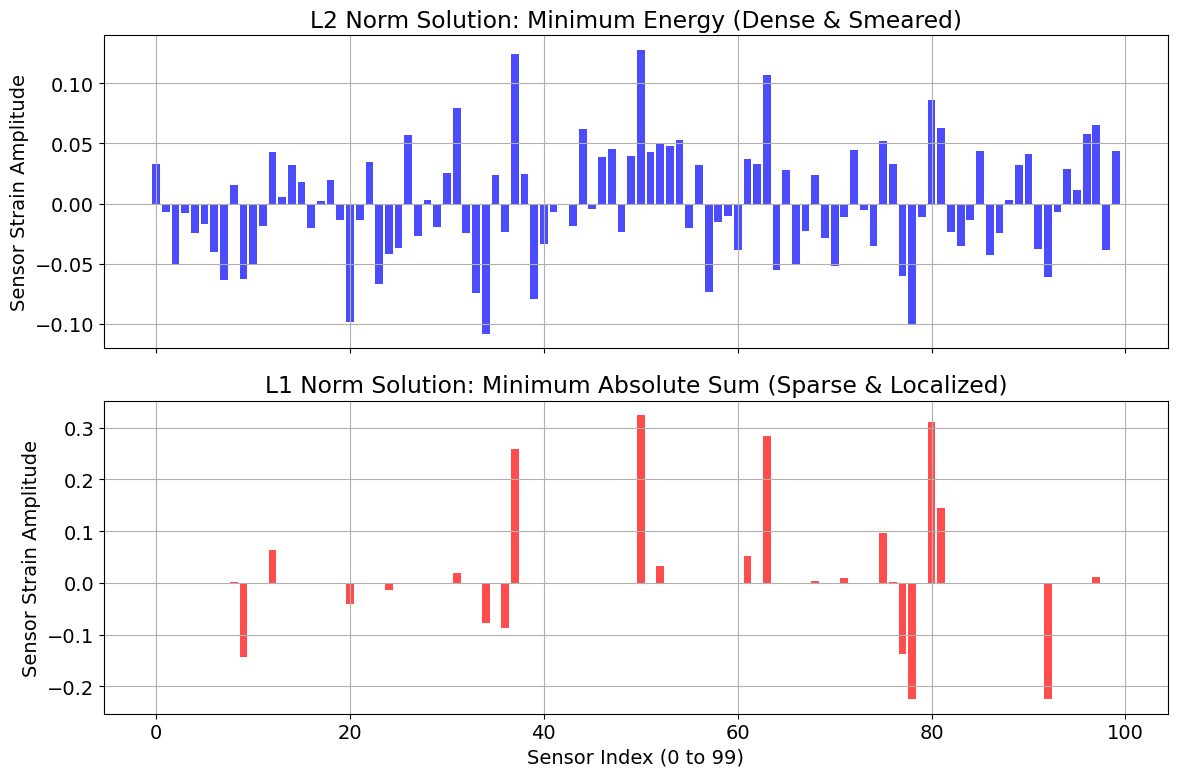

Number of active sensors in L2 solution (> 0.001): 100 out of 100
Number of active sensors in L1 solution (> 0.001): 23 out of 100


In [4]:
# Plotting the L2 and L1 solution vectors to contrast them
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

sensor_indices = np.arange(m_sensors)

# Plot L2 Solution (Dense)
axs[0].bar(sensor_indices, x_L2, color='blue', alpha=0.7)
axs[0].set_title('L2 Norm Solution: Minimum Energy (Dense & Smeared)')
axs[0].set_ylabel('Sensor Strain Amplitude')

# Plot L1 Solution (Sparse)
# Notice how the L1 solution correctly assumes only a handful of sensors are active (compressed sensing)
axs[1].bar(sensor_indices, x_L1, color='red', alpha=0.7)
axs[1].set_title('L1 Norm Solution: Minimum Absolute Sum (Sparse & Localized)')
axs[1].set_ylabel('Sensor Strain Amplitude')
axs[1].set_xlabel('Sensor Index (0 to 99)')

plt.tight_layout()
plt.show()

# Quick sparsity check
tolerance = 1e-3
l2_nonzeros = np.sum(np.abs(x_L2) > tolerance)
l1_nonzeros = np.sum(np.abs(x_L1) > tolerance)

print(f"Number of active sensors in L2 solution (> {tolerance}): {l2_nonzeros} out of 100")
print(f"Number of active sensors in L1 solution (> {tolerance}): {l1_nonzeros} out of 100")

### Challenge Problem: Orthogonal Matching Pursuit (OMP)
While numerical L1 optimization via SLSQP works for compressed sensing, it is slow for massive aerospace systems. The **Orthogonal Matching Pursuit (OMP)** algorithm is a greedy algorithm specifically designed to find highly sparse solutions rapidly. Your challenge: Use `OrthogonalMatchingPursuit` from `sklearn.linear_model` to solve the sensor allocation problem and compare its sparsity to the L1 norm solution.

In [ ]:
# YOUR CODE HERE
# 1. Import OrthogonalMatchingPursuit from sklearn.linear_model
# 2. Fit OMP to our A_mapping and b_measurements (targeting a sparsity of e.g. 5 non-zero sensors)
# 3. Plot the OMP solution as a bar chart
from sklearn.linear_model import OrthogonalMatchingPursuit
# ...

<details>
<summary><b>Click to Reveal Solution</b></summary>

```python
from sklearn.linear_model import OrthogonalMatchingPursuit

# We guess that only ~5 sensors are actually active
# OMP will greedily pick the 5 columns of A that best explain b
omp = OrthogonalMatchingPursuit(n_nonzero_coefs=5)
omp.fit(A_mapping, b_measurements)
x_omp = omp.coef_

# Plotting
plt.figure(figsize=(12, 4))
plt.bar(np.arange(m_sensors), x_omp, color='green', alpha=0.8)
plt.title('OMP Solution: Extremely Sparse (Greedy Algorithm)')
plt.ylabel('Sensor Strain')
plt.xlabel('Sensor Index')
plt.grid(True)
plt.show()

active_omp = np.sum(np.abs(x_omp) > 1e-5)
print(f"Number of active sensors in OMP solution: {active_omp}")
```
</details>